In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression,LogisticRegression


In [ ]:
x=np.array([[1],[2],[3],[4],[5],[6],[7],[8]])
y_reg=np.array([30,40,45,55,65,70,80,90])
y_cls=np.array([0,0,0,0,1,1,1,1])

In [ ]:
lin=LinearRegression()
lin.fit(x,y_reg)
print('Regression output:',lin.predict([[0.73]]))

Regression output: [27.73392857]


In [ ]:
log=LogisticRegression()
log.fit(x,y_cls)
print('classification output',log.predict([[0.73]]))

classification output [0]


In [ ]:
print('probability:',log.predict_proba([[0.73]]))

probability: [[0.98799263 0.01200737]]


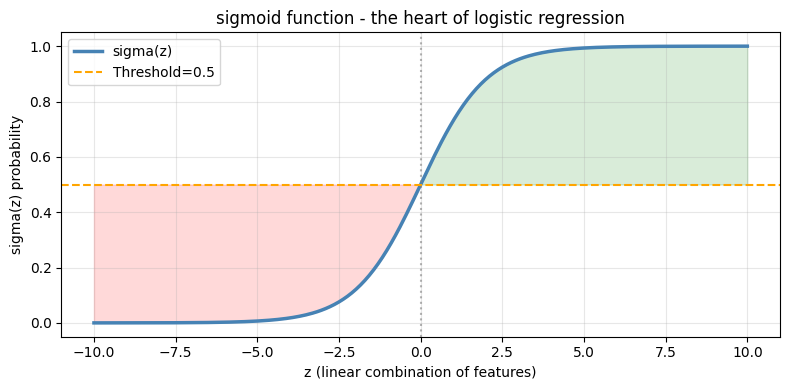

Sigmoid(0)=0.5000
Sigmoid(5)=0.9933
Sigmoid(-5)=0.0067


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
  return 1/(1+np.exp(-z))

z=np.linspace(-10,10,300)


prob=sigmoid(z)
plt.figure(figsize=(8,4))
plt.plot(z,prob,color='steelblue',linewidth=2.5,label='sigma(z)')
plt.axhline(y=0.5,color='orange',linestyle='--',label='Threshold=0.5')
plt.axvline(x=0,color='gray',linestyle=':',alpha=0.6)
plt.fill_between(z,prob,0.5,where=(prob>0.5),alpha=0.15,color='green')
plt.fill_between(z,prob,0.5,where=(prob<0.5),alpha=0.15,color='red')
plt.xlabel('z (linear combination of features)')
plt.ylabel('sigma(z) probability')
plt.title('sigmoid function - the heart of logistic regression')
plt.legend();plt.grid(alpha=0.3);plt.tight_layout();
plt.show()

print(f'Sigmoid(0)={sigmoid(0):.4f}')
print(f'Sigmoid(5)={sigmoid(5):.4f}')
print(f'Sigmoid(-5)={sigmoid(-5):.4f}')

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score,f1_score,recall_score

x,y=make_classification(n_samples=500,n_features=5,weights=[0.7,0.3],random_state=42)

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

model=LogisticRegression()
model.fit(x_train,y_train)

probs=model.predict_proba(x_test)[:,1]
print(f'{'Threshold':>10}{'Precision':>10}{'Recall':>8}{'F1':>6}')
print('_'*45)
for threshold in [0.2,0.3,0.4,0.5,0.6,0.7,0.8]:
  preds=(probs>=threshold).astype(int)
  p=precision_score(y_test,preds,zero_division=0)
  r=recall_score(y_test,preds)
  f1=f1_score(y_test,preds,zero_division=0)
  print(f'{threshold:>10.1f}{p:>10.3f}{r:>8.3f}{f1:>6.3f}')

 Threshold Precision  Recall    F1
_____________________________________________
       0.2     0.696   0.941 0.800
       0.3     0.762   0.941 0.842
       0.4     0.882   0.882 0.882
       0.5     0.882   0.882 0.882
       0.6     0.903   0.824 0.862
       0.7     0.903   0.824 0.862
       0.8     0.958   0.676 0.793


TP=5, TN=4, FP=3, FN=3
Accuracy = (5+4)/15 = 60.00%
Precision = 5/(5+3) = 62.50%
Recall = 5/(5+3) = 62.50%
Confusion Matrix:
 [[4 3]
 [3 5]]


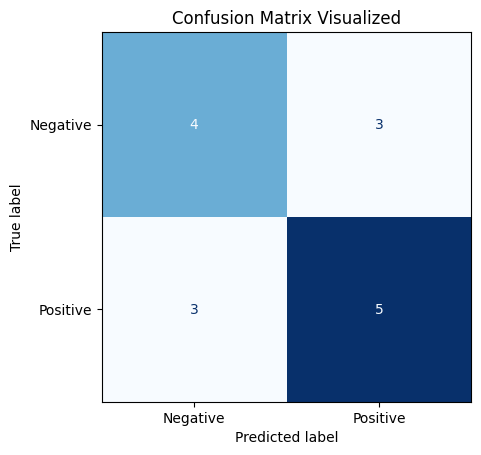

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = [1,1,1,1,1, 0,0,0,0,0, 1,0,1,0,1]
y_pred = [1,1,1,0,0, 0,0,0,1,1, 1,0,0,1,1]

y_true = np.array(y_true)
y_pred = np.array(y_pred)

TP = ((y_pred == 1) & (y_true == 1)).sum()
TN = ((y_pred == 0) & (y_true == 0)).sum()
FP = ((y_pred == 1) & (y_true == 0)).sum()
FN = ((y_pred == 0) & (y_true == 1)).sum()

accuracy = (TP + TN) / len(y_true)
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print(f"TP={TP}, TN={TN}, FP={FP}, FN={FN}")

print(f"Accuracy = ({TP}+{TN})/{len(y_true)} = {accuracy:.2%}")
print(f"Precision = {TP}/({TP}+{FP}) = {precision:.2%}")
print(f"Recall = {TP}/({TP}+{FN}) = {recall:.2%}")

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative','Positive']
)

disp.plot(cmap='Blues', colorbar=False)

plt.title("Confusion Matrix Visualized")
plt.show()

In [ ]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,f1_score,accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np


x_bal,y_bal=make_classification(n_samples=1000,weights=[0.5,0.5],random_state=42)

x_imb,y_imb=make_classification(n_samples=1000,weights=[0.99,0.01],random_state=42)

def evaluate(x,y,label):
  x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
  model=LogisticRegression(max_iter=1000).fit(x_train,y_train)
  y_pred=model.predict(x_test)
  acc=accuracy_score(y_test,y_pred)
  f1=f1_score(y_test,y_pred,zero_division=0)
  print(f"\n++{label}===")
  print(f"accuracy:{acc:.2%}<- {'misleading'if f1<0.5 else 'ok'}")
  print(f"f1-score:{f1:.2%}<-real performance")
  print(classification_report(y_test,y_pred,zero_division=0))

evaluate(x_bal,y_bal,'Balanced Dataset')
evaluate(x_imb,y_imb,'Imbalanced Dataset')


++Balanced Dataset===
accuracy:85.50%<- ok
f1-score:85.57%<-real performance
              precision    recall  f1-score   support

           0       0.80      0.91      0.85        93
           1       0.91      0.80      0.86       107

    accuracy                           0.85       200
   macro avg       0.86      0.86      0.85       200
weighted avg       0.86      0.85      0.86       200


++Imbalanced Dataset===
accuracy:98.00%<- misleading
f1-score:0.00%<-real performance
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       197
           1       0.00      0.00      0.00         3

    accuracy                           0.98       200
   macro avg       0.49      0.50      0.49       200
weighted avg       0.97      0.98      0.98       200



In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x_imb,y_imb,test_size=0.2,random_state=42)
model_fixed=LogisticRegression(class_weight='balanced',max_iter=1000)
model_fixed.fit(x_train,y_train)

y_pred_fixed=model_fixed.fit(x_train,y_train)
y_pred_fixed=model_fixed.predict(x_test)
print('\n===after class eight = balanced ===')
print(classification_report(y_test,y_pred_fixed,zero_division=0))




===after class eight = balanced ===
              precision    recall  f1-score   support

           0       0.99      0.88      0.93       197
           1       0.04      0.33      0.07         3

    accuracy                           0.87       200
   macro avg       0.51      0.61      0.50       200
weighted avg       0.97      0.87      0.92       200



In [ ]:
from sklearn.datasets import make_classification
from sklearn.linear_model import  LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve,roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


x,y=make_classification(n_samples=800,n_features=10,random_state=42)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)


In [ ]:
lr=LogisticRegression().fit(x_train,y_train)
prob_lr=lr.predict_proba(x_test)[:,1]

In [ ]:
dt=DecisionTreeClassifier(max_depth=4).fit(x_train,y_train)
prob_dt=dt.predict_proba(x_test)[:,1]

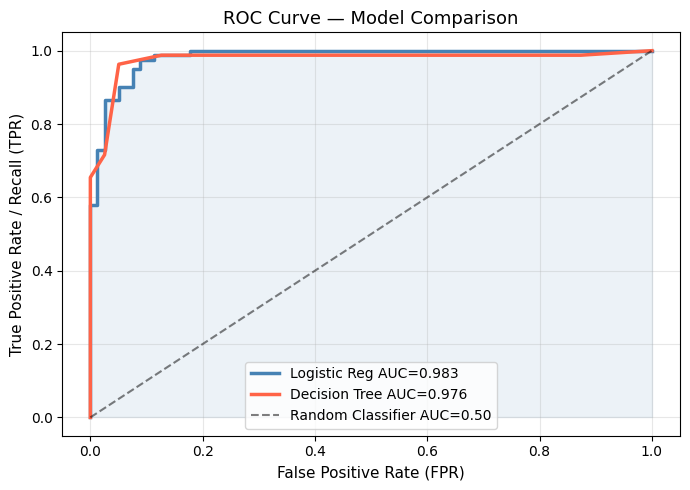

In [ ]:
fpr_lr,tpr_lr,_=roc_curve(y_test,prob_lr)
fpr_dt,tpr_dt,_=roc_curve(y_test,prob_dt)
auc_lr=roc_auc_score(y_test,prob_lr)
auc_dt=roc_auc_score(y_test,prob_dt)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, lw=2.5, color='steelblue', label=f'Logistic Reg AUC={auc_lr:.3f}')
plt.plot(fpr_dt, tpr_dt, lw=2.5, color='tomato', label=f'Decision Tree AUC={auc_dt:.3f}')
plt.plot([0,1],[0,1], 'k--', alpha=0.5, label='Random Classifier AUC=0.50')
plt.fill_between(fpr_lr, tpr_lr, alpha=0.1, color='steelblue')
plt.xlabel('False Positive Rate (FPR)', fontsize=11)
plt.ylabel('True Positive Rate / Recall (TPR)', fontsize=11)
plt.title('ROC Curve — Model Comparison', fontsize=13)
plt.legend(fontsize=10); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [ ]:
print(f'Logistic Regression AUC: {auc_lr:.4f}')
print(f'Decision Tree AUC: {auc_dt:.4f}')
print('Higher AUC = better model at separating classes')

Logistic Regression AUC: 0.9833
Decision Tree AUC: 0.9761
Higher AUC = better model at separating classes
